In [4]:
from json.decoder import NaN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit
import glob
from pathlib import Path
import seaborn as sns
plt.style.use('../natty_style.mplstyle')
twocolors = ['#0000a2','#bc272d']
fourcolors = ['#0000a2','#bc272d','#50ad9f','#e9c716']

def load_3pp_data(filepath):
    """Load 3PP data from CSV"""
    data = pd.read_csv(filepath, comment='#')
    metadata = {}
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                key, val = line[1:].strip().split(':', 1)
                metadata[key.strip()] = val.strip()
    return {
        'time_ns': data['time_ns'].values,
        'voltage_V': data['voltage_V'].values,
        'metadata': metadata
    }

def find_all_peaks(voltage_V, prominence_factor=0.2):
    """Find all peaks in the waveform"""
    peaks, properties = signal.find_peaks(
        voltage_V,
        prominence=prominence_factor * np.max(voltage_V),
        distance=50
    )

    if len(peaks) < 2:
        raise ValueError(f"Expected 2 peaks, found {len(peaks)}")
    if len(peaks) > 2:
        largest = np.argsort(properties['prominences'])[-2:]
        peaks = np.sort(peaks[largest])

    return peaks

def find_rising_edge_before_peak(voltage_V, peak_idx, search_back_ns=20, dt_ns=0.1):
    """Find where rising edge starts before peak"""
    search_samples = int(search_back_ns / dt_ns)
    start_idx = max(0, peak_idx - search_samples)
    threshold = 0.05 * abs(voltage_V[peak_idx])
    for i in range(peak_idx, start_idx, -1):
        if abs(voltage_V[i]) < threshold:
            return i + 1
    return start_idx

def align_peaks(time_ns, voltage_V, metadata, truncate_factor=0.95):
    """Align N and D peaks at their rising edges"""
    pulse_width = float(metadata.get('pulse_width_ns', 200))
    polarity = metadata.get('polarity', 'npp')

    if polarity == 'pnn' or polarity == 'nn':
        voltage_V = -voltage_V
    else:  # npp
        voltage_V = voltage_V

    peaks = find_all_peaks(voltage_V)
    dt_ns = np.mean(np.diff(time_ns))

    # For 2-pulse (UDUU): N is 1st peak, D is 2nd peak
    n_edge_idx = find_rising_edge_before_peak(voltage_V, peaks[0], dt_ns=dt_ns)
    d_edge_idx = find_rising_edge_before_peak(voltage_V, peaks[1], dt_ns=dt_ns)

    window_samples = int(truncate_factor * pulse_width / dt_ns)
    n_end = min(len(time_ns), n_edge_idx + window_samples)
    d_end = min(len(time_ns), d_edge_idx + window_samples)

    return {
        'n_time': time_ns[n_edge_idx:n_end] - time_ns[n_edge_idx],
        'n_voltage': voltage_V[n_edge_idx:n_end],
        'd_time': time_ns[d_edge_idx:d_end] - time_ns[d_edge_idx],
        'd_voltage': voltage_V[d_edge_idx:d_end]
    }

def calculate_polarization(aligned_data, metadata, resistance=50, cd_um=np.nan):
    """
    Calculate P* (N), P^ (D), and dP (difference)
    Returns dictionary suitable for DataFrame construction
    """
    # Interpolate D onto N's time base
    common_time = aligned_data['n_time']
    d_interp = np.interp(common_time, aligned_data['d_time'], aligned_data['d_voltage'])

    # Calculate individual charges
    time_s = common_time * 1e-9

    # N charge (P*)
    current_n = aligned_data['n_voltage'] / resistance
    charge_n_C = np.trapezoid(current_n, time_s)
    if metadata.get('polarity', 'npp') == 'pnn' or metadata.get('polarity', 'npp') == 'nn':
        charge_n_C = -charge_n_C

    # D charge (P^)
    current_d = d_interp / resistance
    charge_d_C = np.trapezoid(current_d, time_s)
    if metadata.get('polarity', 'npp') == 'pnn' or metadata.get('polarity', 'npp') == 'nn':
        charge_d_C = -charge_d_C

    # Get device area
    area_cm2 = float(metadata.get('device_area_cm2', 'nan'))
    if not np.isnan(cd_um):
        area_cm2 = np.pi * (cd_um / 2 * 1e-4) ** 2

    # Build results dictionary
    results = {
        # Metadata
        'polarity': metadata.get('polarity', ''),
        'base_offset': float(metadata.get('base_offset', np.nan)),
        'pulse_width_ns': float(metadata.get('pulse_width_ns', np.nan)),
        'capture_width_ns': float(metadata.get('capture_width_ns', np.nan)),
        'record_length': int(metadata.get('record_length', 0)),
        'num_averages': int(metadata.get('num_averages', 1)),
        'cd_um': cd_um,
        'device_area_cm2': area_cm2,

        'pulse_amplitude': float(metadata.get('pulse_amplitude', np.nan)),
        'u_to_d_delay': float(metadata.get('u_to_d_delay', np.nan)),
        'd_to_u_delay': float(metadata.get('d_to_u_delay', np.nan)),
        'd_to_u_delay_s': float(metadata.get('d_to_u_delay_s', np.nan)),
        'u_to_u_delay': float(metadata.get('u_to_u_delay', np.nan)),

        # Charge values
        'charge_n_pC': charge_n_C * 1e12,
        'charge_d_pC': charge_d_C * 1e12,
        'charge_diff_pC': (charge_n_C - charge_d_C) * 1e12,
    }


    # Calculate polarizations if area provided
    if not np.isnan(area_cm2):
        area_m2 = area_cm2 * 1e-4
        results['P_star_uC_cm2'] = (charge_n_C / area_m2) * 1e2  # P* (N)
        results['P_hat_uC_cm2'] = (charge_d_C / area_m2) * 1e2   # P^ (D)
        results['dP_uC_cm2'] = ((charge_n_C - charge_d_C) / area_m2) * 1e2  # dP
    else:
        results['P_star_uC_cm2'] = np.nan
        results['P_hat_uC_cm2'] = np.nan
        results['dP_uC_cm2'] = np.nan

    # Store waveforms for plotting
    results['_plot_data'] = {
        'time': common_time,
        'n_voltage': aligned_data['n_voltage'],
        'd_voltage': d_interp,
        'difference': aligned_data['n_voltage'] - d_interp
    }

    return results

def plot_analysis(results):
    """Plot aligned pulses and difference from results dictionary"""
    plot_data = results['_plot_data']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # Overlaid pulses
    ax1.plot(plot_data['time'], plot_data['n_voltage'], 'r-', label='N pulse (P*)')
    ax1.plot(plot_data['time'], plot_data['d_voltage'], 'g-', label='D pulse (P^)')
    ax1.axhline(0, color='k', linestyle='--', alpha=0.3)
    ax1.set_xlabel('Time from rising edge (ns)')
    ax1.set_ylabel('Voltage (V)')
    ax1.set_title('Aligned N and D Pulses')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Difference
    ax2.plot(plot_data['time'], plot_data['difference'], 'b-')
    ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
    ax2.fill_between(plot_data['time'], 0, plot_data['difference'], alpha=0.3)
    ax2.set_xlabel('Time from rising edge (ns)')
    ax2.set_ylabel('N - D (V)')
    ax2.grid(alpha=0.3)

    # Add results annotation
    if not np.isnan(results['P_star_uC_cm2']):
        text = (f"P* = {results['P_star_uC_cm2']:.3f} µC/cm²\n"
                f"P^ = {results['P_hat_uC_cm2']:.3f} µC/cm²\n"
                f"dP = {results['dP_uC_cm2']:.3f} µC/cm²")
    else:
        text = (f"Q(N) = {results['charge_n_pC']:.3f} pC\n"
                f"Q(D) = {results['charge_d_pC']:.3f} pC\n"
                f"dQ = {results['charge_diff_pC']:.3f} pC")

    ax2.text(0.02, 0.98, text, transform=ax2.transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

    plt.tight_layout()
    plt.show()

def analyze_3pp_file(filepath, cd_um=np.nan, pulsetrain='3pp'):
    """Analyze a single 3PP/UDUU file and return results dictionary"""
    data = load_3pp_data(filepath)
    aligned = align_peaks(data['time_ns'], data['voltage_V'], data['metadata'])
    results = calculate_polarization(aligned, data['metadata'], cd_um=cd_um)
    results['filename'] = filepath
    results['pulsetrain'] = pulsetrain
    return results

def batch_analyze(directory, save_csv=True, plot_all=False, cd_um=np.nan, pattern='uduu_*.csv'):
    """
    Analyze all 3PP/UDUU files in directory
    Args:
        directory: Path to directory containing CSV files
        pattern: Glob pattern for matching files (default: "3pp_*.csv")
        save_csv: If True, save results to CSV (default: True)
        plot_all: If True, plot every file (default: False, can be slow)
        cd_um: Contact diameter in microns
        pulsetrain: '3pp' for 3-pulse or 'uduu' for 2-pulse
    Returns:
        DataFrame with all results
    """

    search_path = Path(directory) / pattern
    files = sorted(glob.glob(str(search_path)))

    if not files:
        print(f"No files found matching: {search_path}")
        return None

    results_list = []
    for i, filepath in enumerate(files, 1):
        filename = Path(filepath).name
        print(f"[{i}/{len(files)}] Processing: {filename}")

        try:
            results = analyze_3pp_file(filepath, cd_um=cd_um)

            # Remove plot data for DataFrame
            results_for_df = {k: v for k, v in results.items() if not k.startswith('_')}
            results_list.append(results_for_df)

            # Optionally plot each file
            if plot_all:
                plot_analysis(results)

            print(f"  ✓ Success - dP = {results['dP_uC_cm2']:.3f} µC/cm²")
        except Exception as e:
            print(f"  ✗ Error: {e}")
            continue

    print("-" * 60)
    print(f"Successfully analyzed {len(results_list)}/{len(files)} files")

    # Create DataFrame
    if not results_list:
        print("No files were successfully analyzed")
        return None

    df = pd.DataFrame(results_list)

    # Save to CSV if requested
    if save_csv:
        output_filename = f"uduu_analysis_results.csv"
        output_path = Path(directory) / output_filename
        df.to_csv(output_path, index=False)
        print(f"\nResults saved to: {output_path}")

    return df

In [ ]:
import matplotlib.pyplot as plt
def fit_gaussian(x_data, y_data):
    """
    Fit a Gaussian to data and return fit parameters and center point

    Args:
        x_data: x-axis data (e.g., time, position)
        y_data: y-axis data (e.g., voltage, intensity)
        plot: If True, plot the fit

    Returns:
        dict: {
            'center': center of Gaussian (mu),
            'amplitude': peak height,
            'width': standard deviation (sigma),
            'fit_curve': fitted y values,
            'params': (amplitude, center, width)
        }
    """
    # Define Gaussian function
    def gaussian(x, amplitude, center, width):
        return amplitude * np.exp(-(x - center)**2 / (2 * width**2))

    # Initial guess for parameters
    amplitude_guess = np.max(y_data) - np.min(y_data)
    center_guess = x_data[np.argmax(y_data)]
    width_guess = (np.max(x_data) - np.min(x_data)) / 4

    initial_guess = [amplitude_guess, center_guess, width_guess]

    # Fit the Gaussian
    params, covariance = curve_fit(gaussian, x_data, y_data, p0=initial_guess)
    amplitude, center, width = params

    # Generate fitted curve
    fit_curve = gaussian(x_data, amplitude, center, width)

    print(f"Gaussian Fit Results:")
    print(f"  Center (μ): {center:.6f}")
    print(f"  Amplitude: {amplitude:.6f}")
    print(f"  Width (σ): {width:.6f}")

    return {
        'center': center,
        'amplitude': amplitude,
        'width': width,
        'fit_curve': fit_curve,
        'params': params
    }

def fit_tanh(x_data, y_data, plot=True):
    """
    Fit a tanh function to data and return fit parameters and center point

    Args:
        x_data: x-axis data (e.g., time, voltage)
        y_data: y-axis data (e.g., current, response)
        plot: If True, plot the fit

    Returns:
        dict: {
            'center': center/transition point (x0),
            'amplitude': vertical scaling factor,
            'slope': slope at center point,
            'offset': vertical offset,
            'fit_curve': fitted y values,
            'params': (amplitude, center, slope, offset)
        }
    """
    # Define tanh function: amplitude * tanh((x - center) / width) + offset
    def tanh_func(x, amplitude, center, width, offset):
        return amplitude * np.tanh((x - center) / width) + offset

    # Initial guess for parameters
    y_min = np.min(y_data)
    y_max = np.max(y_data)
    amplitude_guess = (y_max - y_min) / 2
    offset_guess = (y_max + y_min) / 2

    # Find steepest point as center guess
    dy = np.gradient(y_data)
    center_idx = np.argmax(np.abs(dy))
    center_guess = x_data[center_idx]

    # Width estimate from transition region
    width_guess = (np.max(x_data) - np.min(x_data)) / 10

    initial_guess = [amplitude_guess, center_guess, width_guess, offset_guess]

    # Fit the tanh function
    params, covariance = curve_fit(tanh_func, x_data, y_data, p0=initial_guess)
    amplitude, center, width, offset = params

    # Calculate slope at center point
    slope = amplitude / width

    # Generate fitted curve
    fit_curve = tanh_func(x_data, amplitude, center, width, offset)

    print(f"Tanh Fit Results:")
    print(f"  Center (x₀): {center:.6f}")
    print(f"  Amplitude: {amplitude:.6f}")
    print(f"  Width: {width:.6f}")
    print(f"  Slope at center: {slope:.6f}")
    print(f"  Offset: {offset:.6f}")

    return {
        'center': center,
        'amplitude': amplitude,
        'slope': slope,
        'width': width,
        'offset': offset,
        'fit_curve': fit_curve,
        'params': params
    }



In [2]:
# if __name__ == "__main__":
#     #################################
#     ##### Single file analysis
#     filepath = r"C:\Users\petermeisenheimer\Shepherd\Archive\data\79-1\ret1-cd20\uduu_pp_A1p2V_DU1000p0ns.csv"
#     data = load_3pp_data(filepath)
#     sns.lineplot(data=data, x='time_ns', y='voltage_V')
#     aligned = align_peaks(data['time_ns'], data['voltage_V'], data['metadata'], pulsetrain='uduu')
#     results = calculate_polarization(aligned, data['metadata'])
#     plot_analysis(results)
#     #################################

In [14]:
if __name__ == "__main__":

    shepherd_data = r"C:\Users\petermeisenheimer\Shepherd\data\\"
    # shepherd_data = r"C:\Users\petermeisenheimer\Shepherd\Archive\data\\"
    sample_directory = r'SP024/A6-cd10/ret1'

    # Run batch analysis
    df = batch_analyze(
        directory=shepherd_data+sample_directory,
        save_csv=True,        # Save results to CSV
        cd_um=10.0,
    )

[1/9] Processing: uduu_analysis_results.csv
  ✗ Error: 'time_ns'
[2/9] Processing: uduu_nn_A1p2V_DU1000000p0ns.csv
  ✓ Success - dP = -8.611 µC/cm²
[3/9] Processing: uduu_nn_A1p2V_DU100000p0ns.csv
  ✓ Success - dP = -8.691 µC/cm²
[4/9] Processing: uduu_nn_A1p2V_DU10000p0ns.csv
  ✓ Success - dP = -9.349 µC/cm²
[5/9] Processing: uduu_nn_A1p2V_DU1000p0ns.csv
  ✓ Success - dP = -10.583 µC/cm²
[6/9] Processing: uduu_pp_A1p2V_DU1000000p0ns.csv
  ✓ Success - dP = 8.772 µC/cm²
[7/9] Processing: uduu_pp_A1p2V_DU100000p0ns.csv
  ✓ Success - dP = 9.473 µC/cm²
[8/9] Processing: uduu_pp_A1p2V_DU10000p0ns.csv
  ✓ Success - dP = 9.933 µC/cm²
[9/9] Processing: uduu_pp_A1p2V_DU1000p0ns.csv
  ✓ Success - dP = 10.700 µC/cm²
------------------------------------------------------------
Successfully analyzed 8/9 files

Results saved to: C:\Users\petermeisenheimer\Shepherd\data\SP024\A6-cd10\ret1\uduu_analysis_results.csv


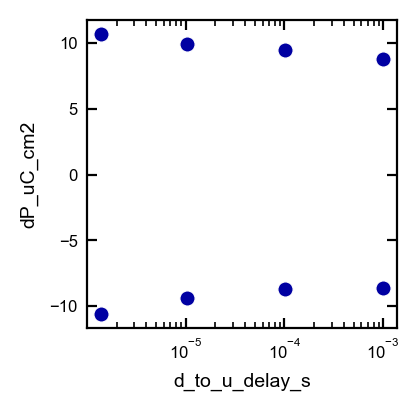

In [15]:
######RET plot
fig, ax = plt.subplots(1,1, figsize = (2,2), dpi=200)
sns.scatterplot(data=df, x=df['d_to_u_delay_s'], y='dP_uC_cm2', s=30, c=twocolors[0])
ax.set_xscale('log')

# result = fit_tanh(df['d_to_u_delay'], abs(df['dP_uC_cm2']))
# cent = result['center']
# ax.text(0.5,0.0*np.max(result['fit_curve']),rf'Vc:{cent:.3f}')
# half = int(len(df['d_to_u_delay'])/2)
# ax.plot(df['nd_amplitude'][:half],
#         result['fit_curve'][:half],
#         'k--', lw=0.5)

ax.set_facecolor('white')
fig.savefig(f'{shepherd_data+sample_directory}plot.png')